# Classification
- in last chapter you made a regression model using different regression models about which you'll study in detail later.
- Now, we may start ML by studying classification.
- We start this by MNIST dataset.
- Load data using sklearn.datasets fetch_openml function.
- sklearn.datasets had mainly 3 functions: fetch_ , load_ and make_

In [1]:
from sklearn.datasets import fetch_openml
mnist=fetch_openml('mnist_784',as_frame=False)

In [2]:
print(mnist.keys())

dict_keys(['data', 'target', 'frame', 'categories', 'feature_names', 'target_names', 'DESCR', 'details', 'url'])


In [3]:
X, y=mnist.data, mnist.target

In [4]:
X

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(70000, 784))

In [5]:
y

array(['5', '0', '4', ..., '4', '5', '6'], shape=(70000,), dtype=object)

In [6]:
y.shape

(70000,)

- Let's take the first digit and try to visualize it.

In [7]:
arr=X[0]
image=arr.reshape(28,28)
print(image)

[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   3  18  18  18 126 136
  175  26 166 255 247 127   0   0   0   0]
 [  0   0   0   0   0   0   0   0  30  36  94 154 170 253 253 253 253 253
  225 172 253 242 195  64   0   0   0   0]
 [  0   0   0   0   0   0   0  49 238 253 253 253 253 253 253 253 253 251
   93  82  82  56  39   0   0   0   0   0]
 [  0   0   0   0   0   0   0  18 219 253 253 253 253 253 198 18

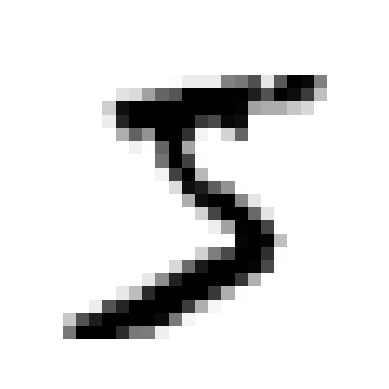

5


In [8]:
import matplotlib.pyplot as plt
plt.imshow(image,cmap='binary')
plt.axis('off')
plt.show()
print(y[0])

### Test set 
- The data is already shuffled so lets just take the first 60k points in training set and the rest in test set.

In [9]:
x_train, x_test, y_train, y_test=X[:60000],X[60000:],y[:60000],y[60000:]

## Training a Binary Classifier
- Let's first train a classifier that distinguishes between 5 and not 5.
- For that we'll first need to alter the target values.

In [10]:
y_train5=(y_train=='5')
y_test5=(y_test=='5')

#### Picking a classifier
- Let's start by choosing SDGClassifier
- It is good for large datasets.
- It trains on each instance independently and hence, is good for online learning too.

In [11]:
from sklearn.linear_model import SGDClassifier
sgd=SGDClassifier(random_state=42)
sgd.fit(x_train,y_train5)

,loss,'hinge'
,penalty,'l2'
,alpha,0.0001
,l1_ratio,0.15
,fit_intercept,True
,max_iter,1000
,tol,0.001
,shuffle,True
,verbose,0
,epsilon,0.1
,n_jobs,None


In [12]:
y_pred=sgd.predict(x_test)

In [13]:
from sklearn.metrics import accuracy_score
print(accuracy_score(y_test5,y_pred))

0.9492


## Measuring Accuracy using Cross-Validation

In [14]:
from sklearn.model_selection import cross_val_score
print(cross_val_score(sgd,x_train,y_train5,cv=4,scoring='accuracy'))

[0.95766667 0.9664     0.96513333 0.95366667]


- It gives good accuracy right.
- No not really, let's see why...
- Let's use DummyClassifier which classifies every instance as the most frequent class.
- So, it will classify every instance as not 5.

In [15]:
from sklearn.dummy import DummyClassifier
dc=DummyClassifier()
print(cross_val_score(dc,x_train,y_train5,cv=3,scoring='accuracy'))

[0.90965 0.90965 0.90965]


- Hence we can see that accuracy is not always a good performance measure for classification tasks.
- Therefore, a better way to evaluate performance is by using Confusion matrix.

## Implementing Custom Cross-Validation
- Over time, you might need more control over it than the inbuilt one can offer.
- Thus, make it custom.

In [16]:
from sklearn.model_selection import StratifiedKFold
from sklearn.base import clone
skf=StratifiedKFold(n_splits=3) # If data is not shuffled, do shuffle = True
for train_index,test_index in skf.split(x_train,y_train5):
    clone_sgd=clone(sgd)
    xf_train,yf_train5,xf_test,yf_test5=x_train[train_index],y_train5[train_index],x_train[test_index],y_train5[test_index]
    clone_sgd.fit(xf_train,yf_train5)
    y_pred=clone_sgd.predict(xf_test)
    correct=sum(y_pred==yf_test5)
    print(correct/len(y_pred))

0.95035
0.96035
0.9604


#### StratifiedKFold:
- It is used to perform stratified sampling.
- It creates folds which contains representative ratio of each class.

## Confusion Matrices

In [17]:
from sklearn.model_selection import cross_val_predict
train_pred=cross_val_predict(sgd,x_train,y_train5,cv=3)

In [18]:
from sklearn.metrics import confusion_matrix
print(confusion_matrix(y_train5,train_pred))

[[53892   687]
 [ 1891  3530]]


- (0,0) shows true negatives
- (0,1) shows false positives
- (1,0) shows False Negatives
- (1,1) shows True positives

- One important measure for accuracy is precision.
- It is calculated as TP/(TP+FP)
- Another is recall/sensitiity/TPR.
- It is calculated as TP/(TP+FN)

In [19]:
# Precision and Recall
from sklearn.metrics import precision_score, recall_score, f1_score
precision_score(y_train5,train_pred)

0.8370879772350012

In [20]:
recall_score(y_train5,train_pred)

0.6511713705958311

In [21]:
# We can calc f1 score which is harmonic mean of precision and recall but, this favours models with similar precision and recall.
# In many cases we want one of them to be high.
# So, we use the precision/recall trade-off

In [22]:
# Precision/Recall trade-off
# sgd classifier : it calculates a score using decision function for each instance and if the score is higher than threshold it classifies as true.
# Let's try to understand...
th_arr = sgd.decision_function([arr])
th_arr

array([2164.22030239])

In [23]:
# sgd uses 0 as threshold, if we increase it, recall will decrease and precision will increase.
thres = 0;
(th_arr-thres)>=0

array([ True])

In [24]:
# Let's try to get the best threshold using visualization.
y_score = cross_val_predict(sgd,x_train,y_train5,cv=3,method='decision_function')

In [25]:
from sklearn.metrics import precision_recall_curve
precision,recall,threshold = precision_recall_curve(y_train5,y_score)

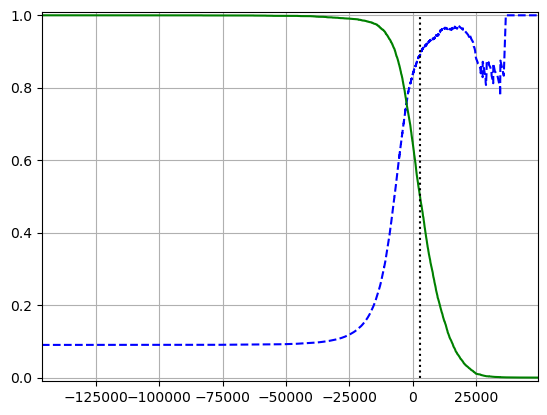

In [26]:
plt.plot(threshold,precision[:-1],'b--')
plt.plot(threshold,recall[:-1],'g-')
plt.vlines(3000,0,1.0,'k','dotted')
plt.axis([threshold.min(),threshold.max(),-0.01,1.01])

plt.grid()
plt.show()

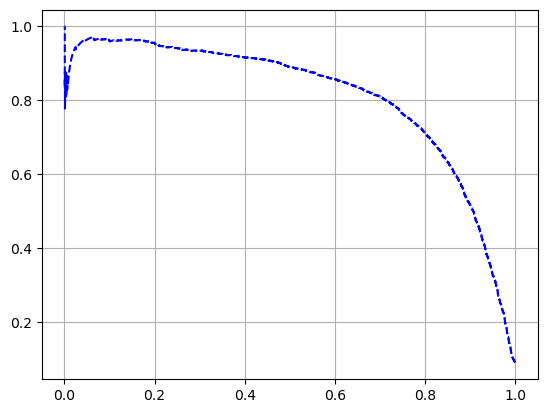

In [27]:
plt.plot(recall,precision,'b--')
plt.grid()
plt.show()

In [28]:
# The choice of precision and recall depends on your specific project.
# default threshold of sgd classifier is 0.
# Let's get the threshold for 90% precision:...
idx_for_90_precision = (precision>=0.90).argmax()
thres = threshold[idx_for_90_precision]
thres

np.float64(3370.019499143955)

In [29]:
precision

array([0.09035   , 0.09035151, 0.09035301, ..., 1.        , 1.        ,
       1.        ], shape=(60001,))

In [30]:
# to make pred, we do:
y_pred_90 = (y_score>=thres)
precision_score(y_train5,y_pred_90)

0.9000345901072293

In [31]:
recall_score(y_train5,y_pred_90)

0.4799852425751706

In [32]:
f1_score(y_train5,y_pred_90)

0.6260827718960539

In [33]:
# If someone says I want my model at 99 percent precision ask at what recall...

In [34]:
# The ROC curve
# Receiver Operating characteristic Curve
# It is the ratio between TPR and FPR(OR 1-TNR)
from sklearn.metrics import roc_curve
fpr, tpr, thresholds = roc_curve(y_train5,y_score)

In [35]:
thresholds

array([             inf,   49441.43765905,   36801.60697028, ...,
       -105763.22240074, -106527.45300471, -146348.56726174],
      shape=(3908,))

In [36]:
# Finding Threshold for 90 percent precision:
idx_for_90 = (thresholds <= thres).argmax()
fpr90, tpr90 = fpr[idx_for_90], tpr[idx_for_90]

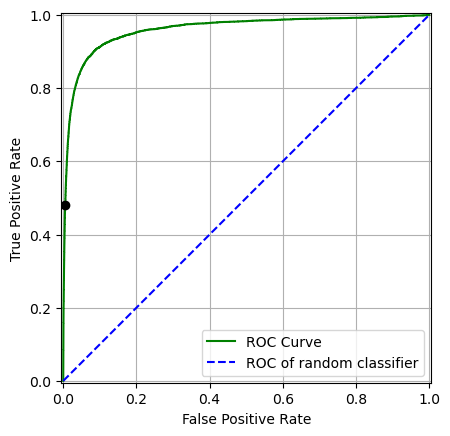

In [37]:
plt.plot(fpr,tpr,'g',label='ROC Curve')
plt.plot([0,1],[0,1],'b--',label='ROC of random classifier')
plt.plot([fpr90],[tpr90],'ko')
plt.axis([-0.005,1.005,-0.005,1.005])

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.gca().set_aspect('equal')
plt.grid()
plt.show()

In [38]:
# a perfect classifier has area under the roc curve as 1
from sklearn.metrics import roc_auc_score
roc_auc_score(y_train5,y_score)

0.9604938554008616

In [39]:
# As a rule of thumb use PR curve when the positive class is rare and vice versa for roc. 

In [40]:
# Now let's train randomforestclassifier
from sklearn.ensemble import RandomForestClassifier
rfc = RandomForestClassifier(random_state=42)
# We don't have any decision function in it so, we use predict_proba method to predict the percent similarity  with each class and take the +ve class as score.
y_proba = cross_val_predict(rfc, x_train, y_train5, method='predict_proba',cv=3)

In [41]:
y_proba

array([[0.11, 0.89],
       [0.99, 0.01],
       [0.96, 0.04],
       ...,
       [0.02, 0.98],
       [0.92, 0.08],
       [0.94, 0.06]], shape=(60000, 2))

In [42]:
# The estimated probability is not equal to actual. To do so, we can use sklearn.calibration
Y_scores = y_proba[:,1]
f_pre, f_rec, f_thr = precision_recall_curve(y_train5,Y_scores)

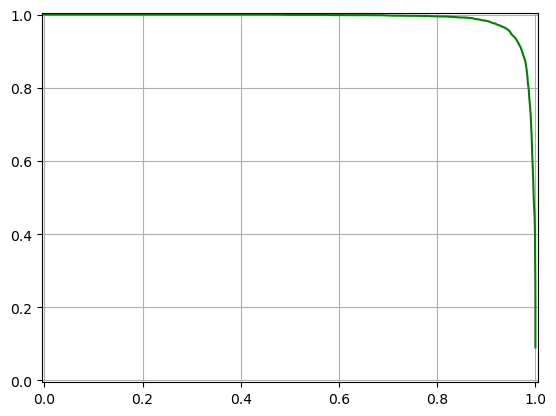

In [43]:
plt.plot(f_rec,f_pre,'g')


plt.axis([-0.005,1.005,-0.005,1.005])
plt.grid()
plt.show()

In [44]:
y_train_pred_f = (Y_scores>=0.5)
f1_score(y_train5,y_train_pred_f)

0.9274509803921569

In [45]:
precision_score(y_train5,y_train_pred_f)

0.9897468089558485

In [46]:
roc_auc_score(y_train5,Y_scores)

0.9983436731328145

In [47]:
# Now we know everything about how to train binary classifiers.

In [48]:
# Multiclass Classification also called multinomial classifiers
# Some sklearn classifiers (logisticregression, randomforestclassifier, gaussiannb, etc) can handle multiple classes.
# While some (sgdclassifier, svc etc) are binary.
# We train them either in OneVsOne manner or OneVsRest/All manner.
# OneVsOne is used for classifiers which are bad at scaling on large data like svc.
# Let's strain svc on first 2000 data points.
# SVC is OvO i.e. 45 classifiers for 10 classes.
from sklearn.svm import SVC
svm = SVC(random_state=42)
svm.fit(x_train[:2000],y_train[:2000])

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [49]:
arr_score=svm.decision_function([arr])

In [50]:
arr_score.argmax()

np.int64(5)

In [51]:
svm.classes_

array(['0', '1', '2', '3', '4', '5', '6', '7', '8', '9'], dtype=object)

In [52]:
# Luckly here the classes are the same as indexes but we won't be this lucky everytime.
# so, we do this:
svm.classes_[arr_score.argmax()]

'5'

In [53]:
# We can force ovo or ovr using the following;
from sklearn.multiclass import OneVsRestClassifier
svm_clf = OneVsRestClassifier(SVC(random_state=42))
svm_clf.fit(x_train[:2000],y_train[:2000])
svm_clf.predict([arr])

array(['5'], dtype='<U1')

In [54]:
len(svm_clf.estimators_)

10

In [55]:
#now let's train the sgd classifier model (it uses default ovr)
sgd_clf = SGDClassifier(random_state=42)
sgd_clf.fit(x_train,y_train)

,loss,'hinge'
,penalty,'l2'
,alpha,0.0001
,l1_ratio,0.15
,fit_intercept,True
,max_iter,1000
,tol,0.001
,shuffle,True
,verbose,0
,epsilon,0.1
,n_jobs,None


In [56]:
sgd_clf.predict([arr])

array(['3'], dtype='<U1')

In [57]:
sgd_clf.decision_function([arr])

array([[-31893.03095419, -34419.69069632,  -9530.63950739,
          1823.73154031, -22320.14822878,  -1385.80478895,
        -26188.91070951, -16147.51323997,  -4604.35491274,
        -12050.767298  ]])

In [58]:
cross_val_score(sgd_clf,x_train,y_train,cv=3,scoring='accuracy')

array([0.87365, 0.85835, 0.8689 ])

In [59]:
# Let's further try to scale the input.
from sklearn.preprocessing import StandardScaler
ss = StandardScaler()
xt_scaled = ss.fit_transform(x_train.astype('float64'))
cross_val_score(sgd_clf,xt_scaled,y_train,cv=3,scoring='accuracy')

array([0.8983, 0.891 , 0.9018])

In [60]:
# Error Analysis
# since there are 10 classes, use confusionmatrixdisplay for a decent view.
from sklearn.metrics import ConfusionMatrixDisplay
y_train_pred = cross_val_predict(sgd_clf,xt_scaled,y_train,cv=3)

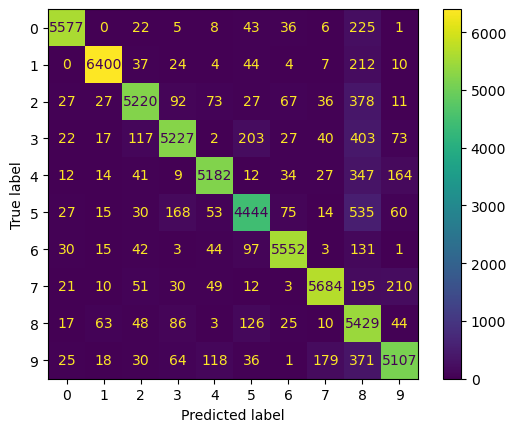

In [61]:
ConfusionMatrixDisplay.from_predictions(y_train,y_train_pred)
plt.show()

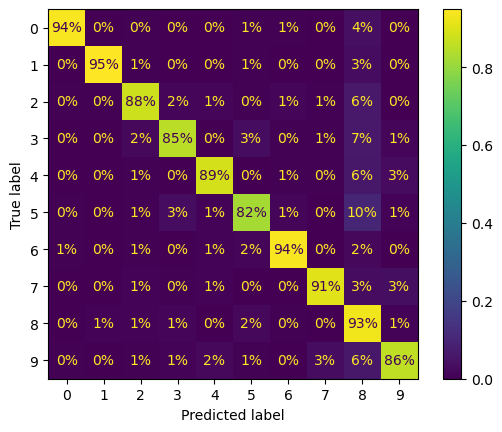

In [62]:
# Let's normalize it so that the darker color at row 5 and col 5 is due to less no. of 5s or not.
ConfusionMatrixDisplay.from_predictions(y_train,y_train_pred,normalize='true',values_format='.0%')
plt.show()

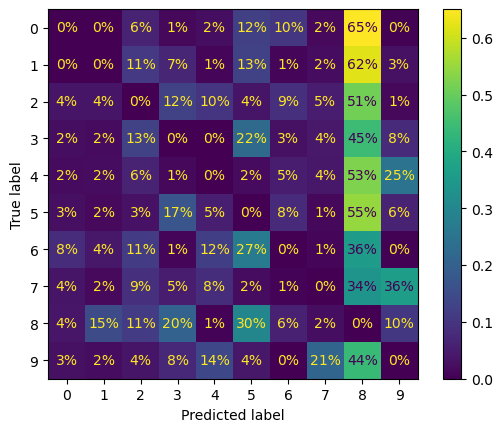

In [63]:
# We can see that the matrix is not symmetric and the model miss classify many numbers as 8.
# now let's make the diagonal sample weights 0 to observe the errors clearly.
ConfusionMatrixDisplay.from_predictions(y_train,y_train_pred,normalize='true',values_format='.0%',sample_weight=(y_train!=y_train_pred))
plt.show()

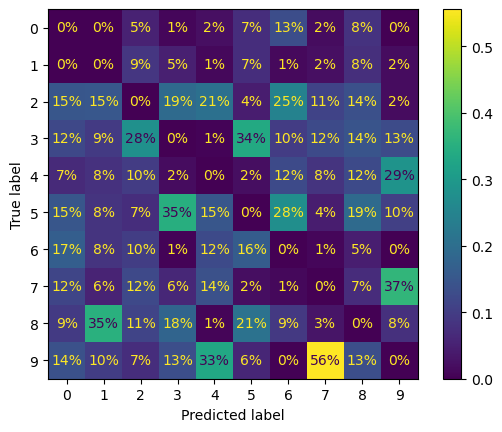

In [64]:
# We can also normalize errors by column
ConfusionMatrixDisplay.from_predictions(y_train,y_train_pred,normalize='pred',values_format='.0%',sample_weight=(y_train!=y_train_pred))
plt.show()

In [65]:
# We see that 56% of misclassified 7s are actually 9s.
# Let's try individual 1v1 plotting 
cl_a , cl_b = '3','5'
x_aa=x_train[(y_train==cl_a)&(y_train_pred==cl_a)]
x_ab=x_train[(y_train==cl_a)&(y_train_pred==cl_b)]
x_ba=x_train[(y_train==cl_b)&(y_train_pred==cl_a)]
x_bb=x_train[(y_train==cl_b)&(y_train_pred==cl_b)]


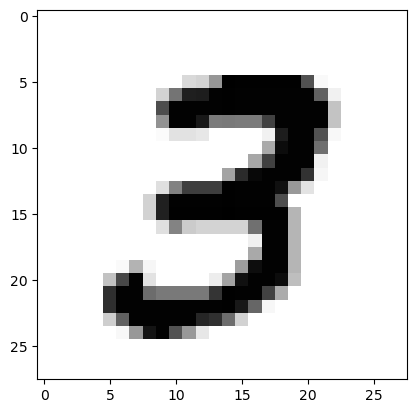

In [66]:
plt.imshow(x_aa[0].reshape(-1,28),cmap='binary')

In [67]:
# The 3/5 confusion can be fixed by data augmentation. By adding slighted shifted and rotated variants to the training set.

In [71]:
# Multilabel Classification
# Sometimes we want our model to output multiple classes for a data point.
# so, we get a boolean array as output.
# Example
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
y_train_large = (y_train>='7')
y_train_odd = (y_train.astype('int8')%2==1)
y_multilabel = np.c_[y_train_large,y_train_odd]
knn_clf = KNeighborsClassifier()
knn_clf.fit(x_train,y_multilabel)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [72]:
knn_clf.predict([arr])

array([[False,  True]])

In [ ]:
# calculating f1 score average
y_train_knnpred = cross_val_predict(knn_clf,x_train,y_multilabel,cv=3)

In [75]:
f1_score(y_multilabel,y_train_knnpred,average='macro')

0.9764102655606048

In [76]:
# Also we migh want to score more on the instances with more frequency, then use accuracy = 'weighted'
f1_score(y_multilabel,y_train_knnpred,average='weighted')

0.9778357403921755

In [77]:
# Now, for models like SVC, we have to do chaining for models to make a multilabel model.
# when we don't use cv, the first model outputs true labels where as using cv hyperparameter it used predicted values.
from sklearn.multioutput import ClassifierChain
cc = ClassifierChain(SVC(),random_state=42,cv=3)
cc.fit(x_train[:2000],y_multilabel[:2000])
cc.predict([arr])

array([[0., 1.]])

In [87]:
# Multioutput Classification
# multout put classifiers can be said as extensions of multilabel classifiers with each label having varying classes/outputs.
# Let's train a multioutput label that takes noisy digit data and outputs clean digit data.
np.random.seed(42)
noise = np.random.randint(0,100,(len(x_train),784))
x_train_mod=x_train+noise
noise = np.random.randint(0,100,(len(x_test),784))
x_test_mod=x_test+noise
y_train_mod=x_train
y_test_mod=y_test

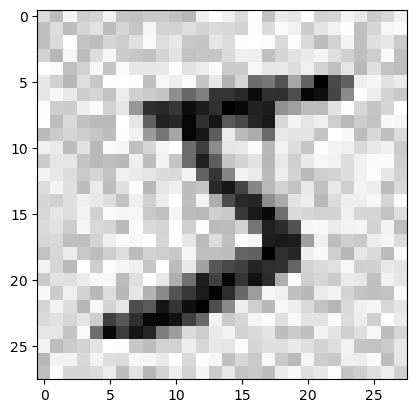

In [99]:
knn_clf = KNeighborsClassifier()
knn_clf.fit(x_train_mod,y_train_mod)
plt.imshow(x_train_mod[0].reshape(-1,28),cmap='binary')


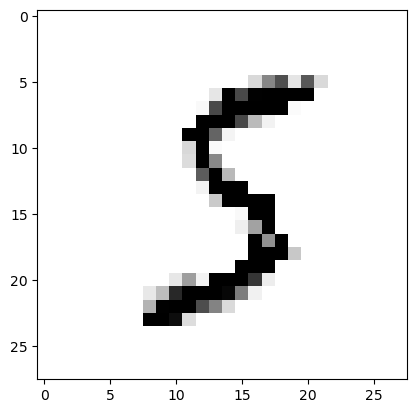

In [100]:
plt.imshow(knn_clf.predict([x_train_mod[0]]).reshape(-1,28),cmap='binary')

In [101]:
# Exercises:
# 1. training a knn on mnist and tuning it.
knn_clf = KNeighborsClassifier()
cross_val_score(knn_clf,x_train,y_train,cv=3,scoring='accuracy')

array([0.9676 , 0.9671 , 0.96755])

In [105]:
from sklearn.model_selection import GridSearchCV
param = {
    'n_neighbors': [3,5,7,9],
    'weights':['uniform','distance']
}
grid = GridSearchCV(knn_clf,param,cv=3,scoring='accuracy')
grid.fit(x_train,y_train)

,estimator,KNeighborsClassifier()
,param_grid,"{'n_neighbors': [3, 5, ...], 'weights': ['uniform', 'distance']}"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_neighbors,3


In [106]:
grid.best_params_

{'n_neighbors': 3, 'weights': 'distance'}

In [110]:
grid.cv_results_

{'mean_fit_time': array([0.18201462, 0.18696809, 0.18066072, 0.18561308, 0.18303982,
        0.18209815, 0.18066947, 0.1831762 ]),
 'std_fit_time': array([0.00540021, 0.00394826, 0.0038887 , 0.00385244, 0.00323425,
        0.0161087 , 0.00474523, 0.00278955]),
 'mean_score_time': array([16.13471516, 16.12489581, 20.91762137, 21.19907371, 21.24904299,
        21.24895827, 20.88965583, 20.83970483]),
 'std_score_time': array([0.15268002, 0.17677639, 0.19904578, 0.41138846, 0.38119252,
        0.50711729, 0.41697366, 0.29027451]),
 'param_n_neighbors': masked_array(data=[3, 3, 5, 5, 7, 7, 9, 9],
              mask=[False, False, False, False, False, False, False, False],
        fill_value=999999),
 'param_weights': masked_array(data=['uniform', 'distance', 'uniform', 'distance',
                    'uniform', 'distance', 'uniform', 'distance'],
              mask=[False, False, False, False, False, False, False, False],
        fill_value=np.str_('?'),
             dtype=object),
 'param

In [111]:
final_model = grid.best_estimator_

In [112]:
y_pred = final_model.predict(x_test)
accuracy_score(y_pred,y_test)

0.9717

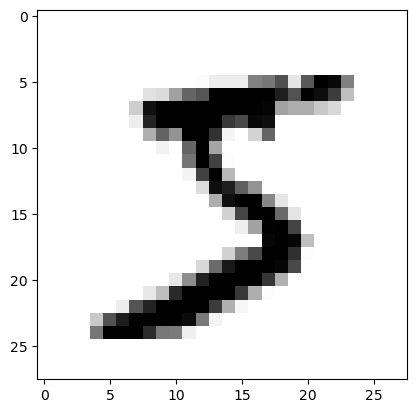

In [121]:
# moving image my set no. of pixels
from scipy.ndimage import shift
plt.imshow(arr.reshape(-1,28),cmap='binary')

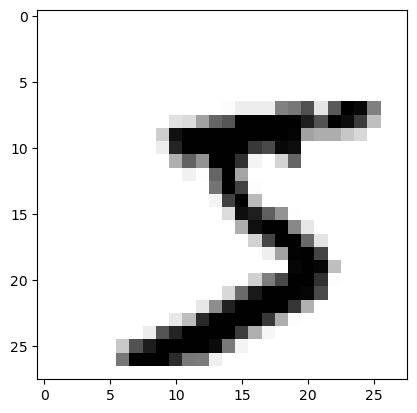

In [124]:
plt.imshow(shift(arr.reshape(-1,28),[2,2],cval=0),cmap='binary')

In [125]:
# We can shift all the image in 4 directions and add these new images to data.
# This makes the model better.
# checking other models:
rf = RandomForestClassifier()
cross_val_score(rf,x_train,y_train,cv=3,scoring='accuracy')

array([0.9653 , 0.96265, 0.96685])

In [137]:
#
sv = SVC(random_state=42)
params= {'C':[8,10,11], 'gamma':[0.02,0.01,0.04], 'kernel':['rbf']}
gg=GridSearchCV(sv,params,cv=3,scoring='accuracy')

In [ ]:
gg.fit(x_train/255,y_train)

In [ ]:
gg.best_score_


In [ ]:
# We can also make a spam classifier...